### This is analysis for data in a train view


This analysis is split into 2 parts, one gives you an html file that shows the train's journey on a specific date, along with the incidents that affected it and the corresponding delays. The second part assesses some stats (connected to reliability)  for that train service code for its year-based data.

**Parameters:**

inputs:

- `train origin and destination`
- `date`


outputs:

- `overall train journey`: what did the train encounter?

In [1]:
# Import required libraries for station_view function
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime, timedelta
import sys
import matplotlib.pyplot as plt
import geopandas as gpd
import json
import folium
from folium import plugins

# Ensure project root is in Python path
project_root = os.path.dirname(os.getcwd())  # Go up from demos to RDM_analysis
if project_root not in sys.path:
    sys.path.insert(0, project_root)

try:
    import importlib
    import rdmpy.outputs.utils
    importlib.reload(rdmpy.outputs.utils)  # ✅ Reload to pick up updated function with incident STANOX merging
    from rdmpy.outputs.utils import train_view, get_stanox_for_service, map_train_journey_with_incidents, train_view_2, plot_reliability_graphs
    print("✅ Successfully imported train analysis functions")
    print("✅ Updated: Now includes stations from incident results with delays")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Make sure you're running from the RDM_analysis directory")
except Exception as e:
    print(f"❌ Error: {e}")

station_view_yearly function ready!
plot_trains_in_system_vs_delay function ready!
explore_delay_outliers function ready!
station_view_yearly function ready!
plot_trains_in_system_vs_delay function ready!
explore_delay_outliers function ready!
✅ Successfully imported train analysis functions
✅ Updated: Now includes stations from incident results with delays


Loading processed data

In [2]:
from rdmpy.outputs.load_data import load_processed_data

all_data = load_processed_data()

✅ Loaded 10,519,554 rows from 2606 files. Skipped 0.


just for quick access for columns

In [3]:
all_data.columns.tolist() # Display the columns of the combined DataFrame

['TRAIN_SERVICE_CODE',
 'PLANNED_ORIGIN_LOCATION_CODE',
 'PLANNED_ORIGIN_GBTT_DATETIME',
 'PLANNED_DEST_LOCATION_CODE',
 'PLANNED_DEST_GBTT_DATETIME',
 'PLANNED_CALLS',
 'ACTUAL_CALLS',
 'PFPI_MINUTES',
 'INCIDENT_REASON',
 'INCIDENT_NUMBER',
 'EVENT_TYPE',
 'SECTION_CODE',
 'DELAY_DAY',
 'EVENT_DATETIME',
 'INCIDENT_START_DATETIME',
 'ENGLISH_DAY_TYPE',
 'STATION_ROLE',
 'DFT_CATEGORY',
 'PLATFORM_COUNT',
 'DATASET_TYPE',
 'WEEKDAY',
 'STANOX',
 'DAY']

### OD pair + DATE

In [4]:
date_str = '07-DEC-2024'
origin = '12931'
destination = '54311'
result_1 = train_view(all_data, origin, destination, date_str)
result_2 = train_view(all_data, destination, origin, date_str)

c:\Users\39342\University of Glasgow\Ji-Eun Byun - MZ-JB\rdmpy\rdmpy\outputs\utils.py:2193: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['INCIDENT_START_DATETIME'] = pd.to_datetime(all_data['INCIDENT_START_DATETIME'], errors='coerce')


Train journeys between 12931 and 54311: 3357 records found.
Unique train service codes: ['21700001', '21701001', '72030304', '21499320', '21499330', '52495117', '21708012', '52495115']
16 incident(s) found for OD pair 12931_54311 on 07-DEC-2024:


,TRAIN_SERVICE_CODE,PLANNED_ORIGIN_LOCATION_CODE,PLANNED_ORIGIN_GBTT_DATETIME,PLANNED_DEST_LOCATION_CODE,PLANNED_DEST_GBTT_DATETIME,PLANNED_CALLS,ACTUAL_CALLS,PFPI_MINUTES,INCIDENT_REASON,INCIDENT_NUMBER,...,EVENT_DATETIME,INCIDENT_START_DATETIME,ENGLISH_DAY_TYPE,STATION_ROLE,DFT_CATEGORY,PLATFORM_COUNT,DATASET_TYPE,WEEKDAY,STANOX,DAY
104876,21700001,12931,0445,54311,0810,0508,0511,3.0,OC,62645.0,...,07-DEC-2024 05:11,2024-12-07 05:11:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,13702,SA
275259,21700001,12931,0445,54311,0810,0600,0603,3.0,TH,62914.0,...,07-DEC-2024 06:03,2024-12-07 05:26:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,16416,SA
288579,21700001,12931,1315,54311,1635,1420,1428,8.0,X4,64326.0,...,08-DEC-2024 14:28,2024-12-07 08:23:00,[SU],None,NaN,NaN,SINGLE_DAY,SU,16416,SU
2692306,21700001,12931,0600,54311,0910,0800,0803,3.0,JL,62913.0,...,07-DEC-2024 08:03,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,44304,SA
2692349,21700001,12931,0630,54311,0938,0824,0829,5.0,JL,62913.0,...,07-DEC-2024 08:29,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,44304,SA
2711093,21700001,12931,0600,54311,0910,0800,0803,3.0,JL,62913.0,...,07-DEC-2024 08:03,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,44421,SA
2711146,21700001,12931,0630,54311,0938,0824,0829,5.0,JL,62913.0,...,07-DEC-2024 08:29,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,44421,SA
2760781,21700001,12931,0526,54311,0838,0830,0834,4.0,JL,62913.0,...,07-DEC-2024 08:34,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,45106,SA
2760833,21700001,12931,0600,54311,0910,0835,0840,5.0,JL,62913.0,...,07-DEC-2024 08:40,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,45106,SA
2760955,21700001,12931,0630,54311,0938,0848,0851,3.0,JL,62913.0,...,07-DEC-2024 08:51,2024-12-07 06:45:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,45106,SA


Train journeys between 54311 and 12931: 11120 records found.
Unique train service codes: ['21700001', '21499330', '21499320', '72030304', '21701001']
18 incident(s) found for OD pair 54311_12931 on 07-DEC-2024:


,TRAIN_SERVICE_CODE,PLANNED_ORIGIN_LOCATION_CODE,PLANNED_ORIGIN_GBTT_DATETIME,PLANNED_DEST_LOCATION_CODE,PLANNED_DEST_GBTT_DATETIME,PLANNED_CALLS,ACTUAL_CALLS,PFPI_MINUTES,INCIDENT_REASON,INCIDENT_NUMBER,...,EVENT_DATETIME,INCIDENT_START_DATETIME,ENGLISH_DAY_TYPE,STATION_ROLE,DFT_CATEGORY,PLATFORM_COUNT,DATASET_TYPE,WEEKDAY,STANOX,DAY
67593,21700001,54311,2000,12931,2306,2359,0007,8.0,OU,63426.0,...,08-DEC-2024 00:07,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,12931,SA
106306,21700001,54311,2000,12931,2306,2341,2346,5.0,OU,63426.0,...,07-DEC-2024 23:46,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,13702,SA
174622,21700001,54311,2100,12931,0001,0001,0004,3.0,OU,63426.0,...,08-DEC-2024 00:04,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,15866,SA
179110,21700001,54311,2000,12931,2306,2319,2323,4.0,OU,63426.0,...,07-DEC-2024 23:23,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,15866,SA
283637,21700001,54311,1830,12931,2141,2135,2138,3.0,OU,63426.0,...,07-DEC-2024 21:38,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,16416,SA
284099,21700001,54311,1930,12931,2240,2231,2239,8.0,OU,63426.0,...,07-DEC-2024 22:39,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,16416,SA
284113,21700001,54311,2000,12931,2306,2234,2246,12.0,OU,63426.0,...,07-DEC-2024 22:46,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,16416,SA
284303,21700001,54311,2100,12931,0001,2319,2330,11.0,OU,63426.0,...,07-DEC-2024 23:30,2024-12-07 04:00:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,16416,SA
794501,21700001,54311,2100,12931,0001,2238,2243,5.0,MD,64595.0,...,07-DEC-2024 22:43,2024-12-07 18:04:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,23491,SA
794512,21700001,54311,2100,12931,0001,2249,2252,3.0,MD,64595.0,...,07-DEC-2024 22:52,2024-12-07 18:04:00,[SA],None,NaN,NaN,SINGLE_DAY,SA,23491,SA


In [5]:
service_code = '21700001'
service_stanox = get_stanox_for_service(all_data, service_code, origin, destination, date_str=date_str)

m = map_train_journey_with_incidents(
    all_data,
    service_stanox,
    incident_results=[result_1, result_2]
    ,service_code=service_code,
    date_str=date_str
)

m.save(f"train_view_{service_code}_{origin}_{destination}_{date_str}.html")

✅ Filtered to date: 07-DEC-2024
✅ Retrieved ALL stations for service 21700001 on OD pair 12931_54311
   Total unique stations: 11
   Stations: ['13702', '16416', '44304', '44421', '45106', '45201', '53221', '53223', '54238', '12931', '54311']
📍 Found 13 additional stations from incident results with delays
📊 Total unique stations: 13
   - From service: 11
   - From incidents: 13
   - Combined: 13
📍 Found 13 stations with coordinates
   1. Newcastle (12931)
   2. Peterborough (45106)
   3. Newark North Gate (44304)
   4. Stevenage (53223)
   5. Hitchin (53221)
   ... and 8 more
🔗 Computing route connections based on geographic proximity...
   ✅ Created 12 route connections based on minimum spanning tree
📍 Creating incident markers for 9 sections...
✅ Created 7 incident markers on map
✅ Map created with proximity-based connections!


### Stats for this train service code (not date dependent)

**Updated:** Both `train_view_2()` and `plot_reliability_graphs()` now analyze ALL stations:
- Stations from the service route (`get_stanox_for_service`)
- Additional stations that experienced delays for this service code
- Complete reliability metrics across the entire affected network

📍 Found 24 additional stations with delays for service 21700001
📊 Total unique stations for analysis: 24
   - From service route: 11
   - With delays: 24
   - Combined: 24
📍 Found 24 additional stations with delays for plotting
📊 Plotting delay distributions for 24 stations


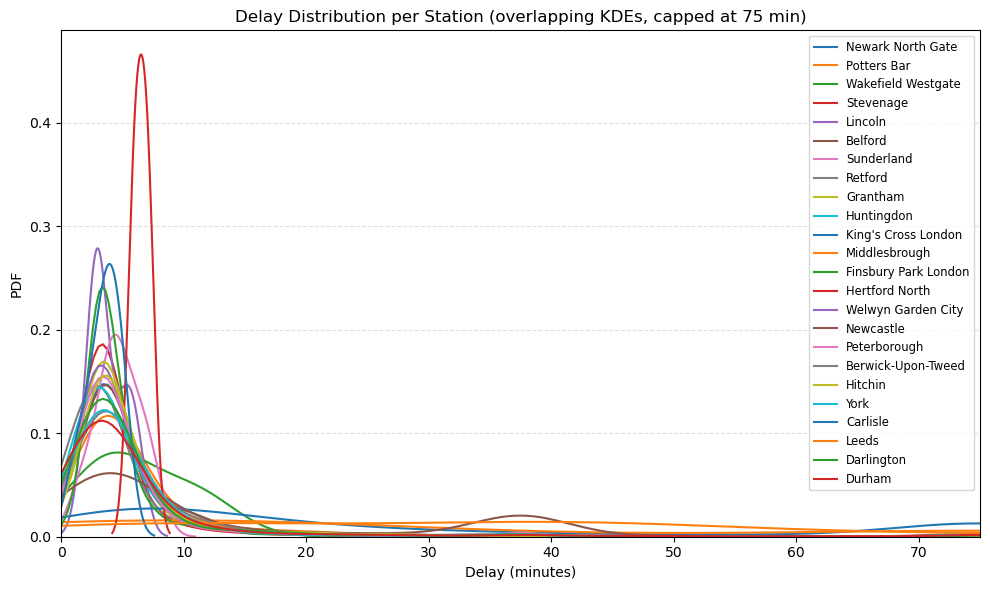

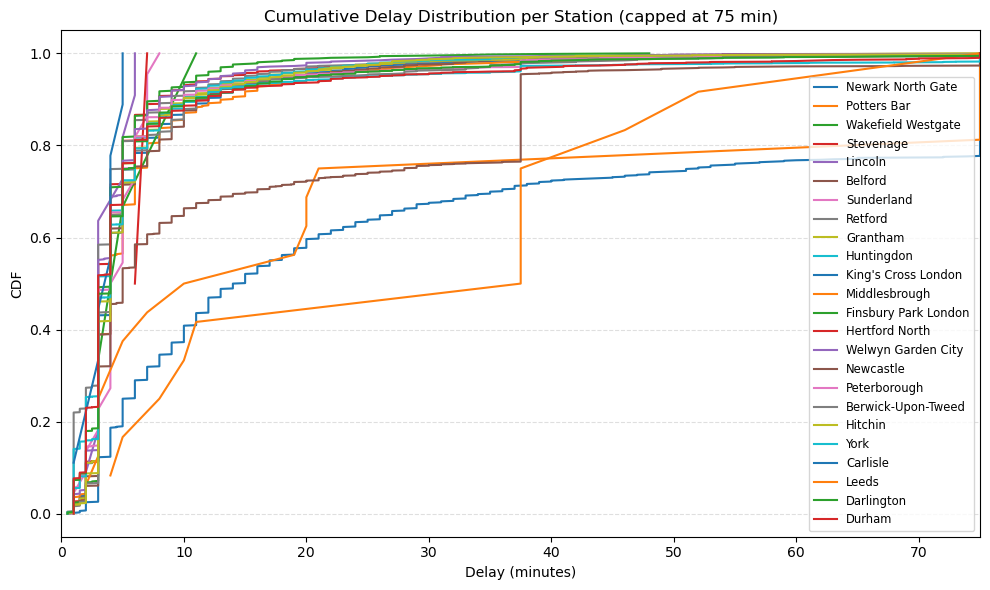

In [6]:
result_table = train_view_2(all_data, service_stanox, service_code)

result_table

plot_reliability_graphs(all_data, service_stanox, service_code) # service_stanox is the list of stations for this service code

Different Incidents: Each route segment encounters different incidents:

79304_73000 (Swansea → Paddington): Affected by Incident 62537 starting at 00:01 at section 77301

77301_73000 (Cardiff → Paddington): No data exists, so no incidents shown